#### Q1

In [1]:
# C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>python q6_test.py
# {'conversion_probability': 0.49999999999842815, 'conversion': False}

#### Q2

In [2]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl cluster-info
# Kubernetes control plane is running at https://127.0.0.1:56349
# CoreDNS is running at https://127.0.0.1:56349/api/v1/namespaces/kube-system/services/kube-dns:dns/proxy

#### Q3

What's the smallest deployable computing unit that we can create and manage in Kubernetes (kind in our case)?

Answer: Pod


#### Q4

What's the Type of the service that is already running there?

Answer: ClusterIP


In [3]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl get services
# NAME         TYPE        CLUSTER-IP   EXTERNAL-IP   PORT(S)   AGE
# kubernetes   ClusterIP   10.96.0.1    <none>        443/TCP   2m46s

#### Q5

To be able to use the docker image we previously created (zoomcamp-model:3.13.10-hw10), we need to register it with kind.

What's the command we need to run for that?

Answer: kind load docker-image

#### Q6

In [4]:
# kubectl apply -f deployment.yaml

In [5]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl apply -f deployment.yaml
# deployment.apps/subscription created

In [6]:
# kubectl get pods

In [7]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl get pods
# NAME                            READY   STATUS             RESTARTS   AGE
# subscription-7fc49b989f-4vbmz   0/1     ImagePullBackOff   0          26s

#### Q7

In [8]:
# apiVersion: v1
# kind: Service
# metadata:
#   name: <Service name>
# spec:
#   type: LoadBalancer
#   selector:
#     app: <???>
#   ports:
#   - port: 80
#     targetPort: <PORT>

Fill it in. What do we need to write instead of <???>?

Answer: subscription

In [9]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl apply -f service.yaml
# service/subscription created


In [10]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kind load docker-image zoomcamp-model:3.13.10-hw10
# Image: "zoomcamp-model:3.13.10-hw10" with ID "sha256:12bd7e33aa71c62641a31478cee51f5f36d6a6337c7685cc5e06fee38c6386a6" not yet present on node "kind-control-plane", loading...

# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl get pods
# NAME                            READY   STATUS    RESTARTS   AGE
# subscription-7fc49b989f-4vbmz   1/1     Running   0          10m

# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl port-forward service/subscription 9696:80
# Forwarding from 127.0.0.1:9696 -> 9696
# Forwarding from [::1]:9696 -> 9696

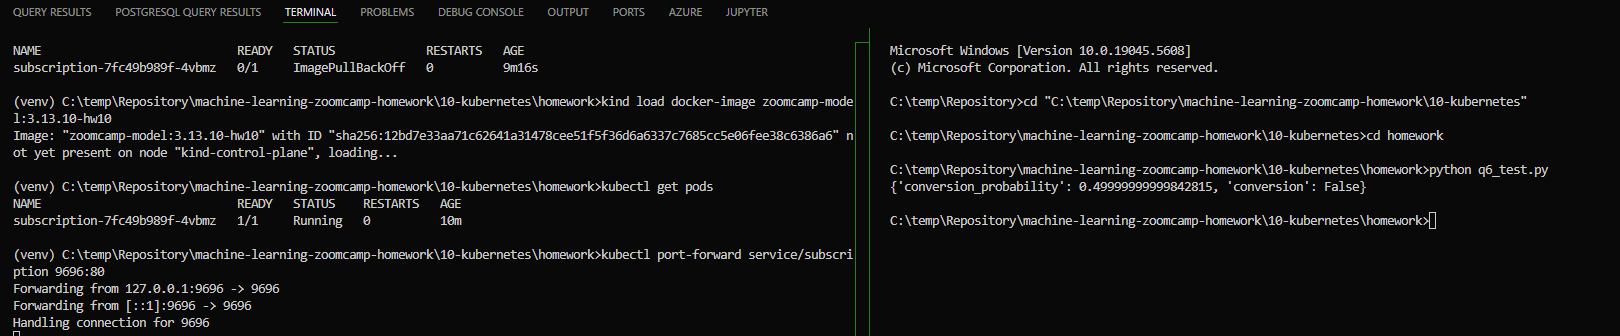

In [11]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl autoscale deployment subscription --name subscription-hpa --cpu-percent=20 --min=1 --max=3
# horizontalpodautoscaler.autoscaling/subscription-hpa autoscaled

In [12]:
# (venv) C:\temp\Repository\machine-learning-zoomcamp-homework\10-kubernetes\homework>kubectl get hpa
# NAME               REFERENCE                 TARGETS              MINPODS   MAXPODS   REPLICAS   AGE
# subscription-hpa   Deployment/subscription   cpu: <unknown>/20%   1         3         1          20s

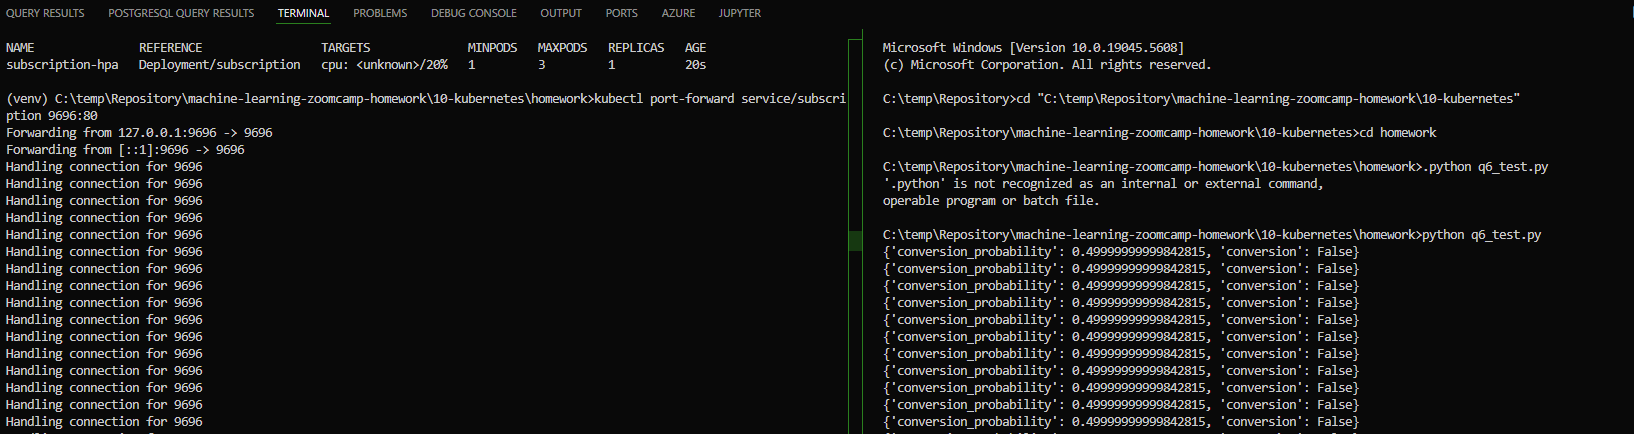

#### Q8

Run kubectl get hpa subscription-hpa --watch command to monitor how the autoscaler performs. Within a minute or so, you should see the higher CPU load; and then - more replicas. What was the maximum amount of the replicas during this test?

Answer : 1

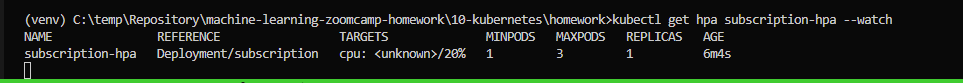